# Table of Contents

- [kNN vs Dimensions](#ZQRX6E9uNccS)
- [Decision Tree vs Dimensions](#IkBPYVOMN-Vq)
- [SVM vs Dimensions](#H30CbSjWONCI)

# kNN vs Dimensions
<a name="ZQRX6E9uNccS"></a>


Processing D = 2 features (n_samples=5000)...
Optimal k found: 12. (Best CV Score: 0.9194)

Processing D = 3 features (n_samples=5000)...
Optimal k found: 12. (Best CV Score: 0.9358)

Processing D = 9 features (n_samples=5000)...
Optimal k found: 13. (Best CV Score: 0.9632)

Processing D = 10 features (n_samples=5000)...
Optimal k found: 17. (Best CV Score: 0.9706)


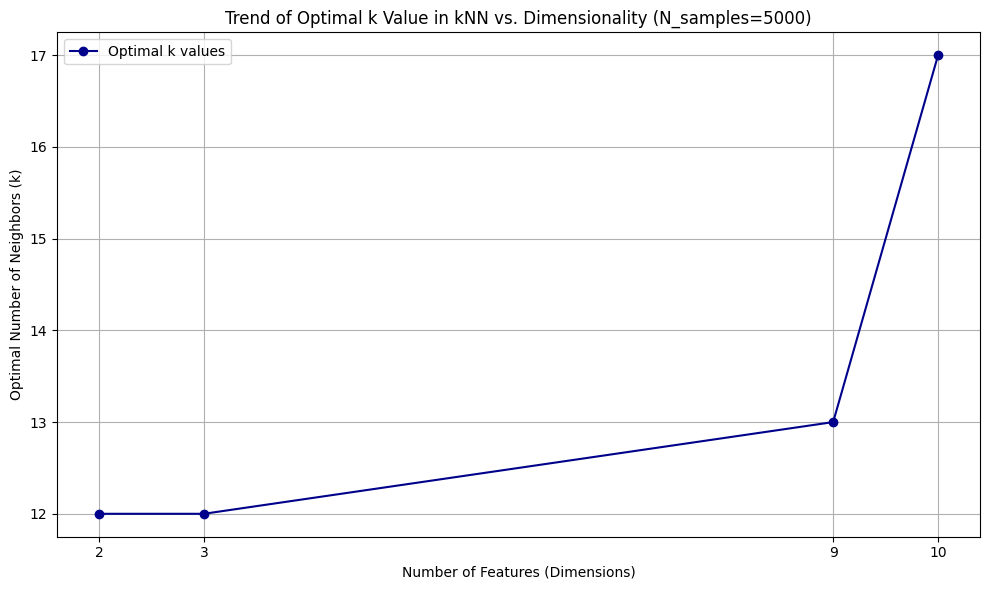

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV


n = 5000
randomseed = 42
dimensions_to_test = [2, 3, 9, 10] #trying to catch a trend
K_range = [12, 13, 14, 15, 16, 17]
optimal_k_results = {}

for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")

    #remove the flip_y, then it'll be set to the default : 0.01
    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    #scalling is important
    pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())


    param_grid = {'kneighborsclassifier__n_neighbors': K_range}
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X, y)



    optimal_k = grid_search.best_params_['kneighborsclassifier__n_neighbors']
    optimal_k_results[D] = optimal_k

    print(f"Optimal k found: {optimal_k}. (Best CV Score: {grid_search.best_score_:.4f})")


dimensions = list(optimal_k_results.keys())
optimal_ks = list(optimal_k_results.values())

#plotting
plt.figure(figsize=(10, 6))
plt.plot(dimensions, optimal_ks, marker='o', linestyle='-', color='darkblue', label='Optimal k values')
plt.xlabel('Number of Features (Dimensions)')
plt.ylabel('Optimal Number of Neighbors (k)')
plt.title(f'Trend of Optimal k Value in kNN vs. Dimensionality (N_samples={n})')
plt.grid(True)
plt.xticks(dimensions, labels=dimensions)
plt.legend()
plt.tight_layout()
plt.show()



---



# Decision tree vs Dimensions
<a name="IkBPYVOMN-Vq"></a>


Processing D = 2 features (n_samples=5000)...
Optimal depth found: 5. (Best CV Score: 0.9076)

Processing D = 3 features (n_samples=5000)...
Optimal depth found: 8. (Best CV Score: 0.9246)

Processing D = 4 features (n_samples=5000)...
Optimal depth found: 10. (Best CV Score: 0.8866)

Processing D = 5 features (n_samples=5000)...
Optimal depth found: 7. (Best CV Score: 0.9012)

Processing D = 6 features (n_samples=5000)...
Optimal depth found: 12. (Best CV Score: 0.8668)


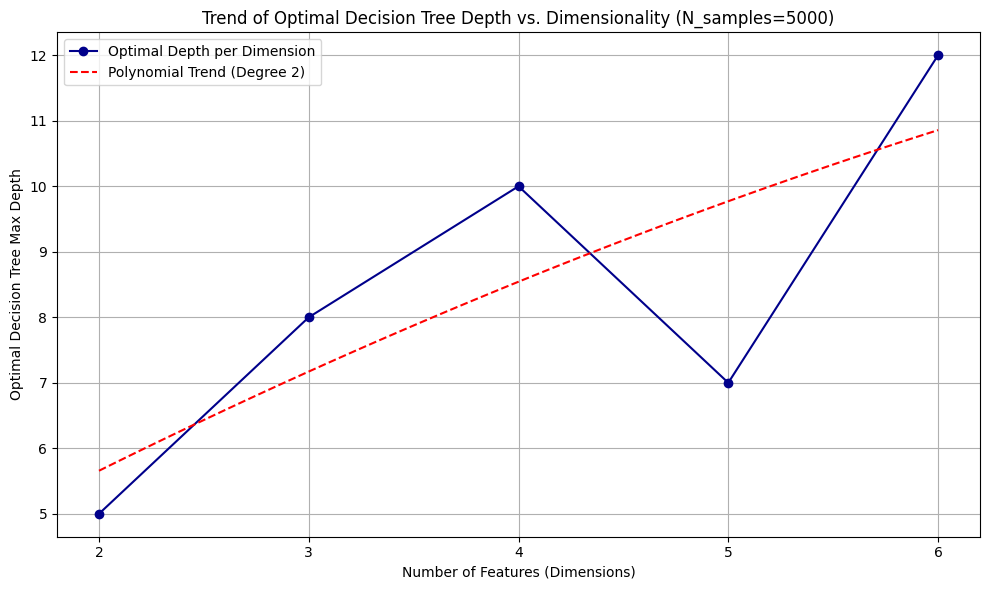

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

n = 5000
randomseed = 42
dimensions_to_test = list(range(2, 7))
depth_range = np.arange(1, 20)

optimal_depth_results = {}

for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")

    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    dtree = DecisionTreeClassifier(random_state=randomseed)

    param_grid = {'max_depth': depth_range}
    grid_search = GridSearchCV(dtree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    grid_search.fit(X, y)

    optimal_depth = grid_search.best_params_['max_depth']
    optimal_depth_results[D] = optimal_depth

    print(f"Optimal depth found: {optimal_depth}. (Best CV Score: {grid_search.best_score_:.4f})")

dimensions = list(optimal_depth_results.keys())
optimal_depths = list(optimal_depth_results.values())

#arrays for plotting
dimensions_np = np.array(dimensions)
optimal_depths_np = np.array(optimal_depths)

#polynomial for catching the trend
degree = 2
coeffs = np.polyfit(dimensions_np, optimal_depths_np, degree)
poly_function = np.poly1d(coeffs)


x_trend = np.linspace(min(dimensions), max(dimensions), 100)
y_trend = poly_function(x_trend)

plt.figure(figsize=(10, 6))
plt.plot(dimensions, optimal_depths, marker='o', linestyle='-', color='darkblue', label='Optimal Depth per Dimension')
plt.plot(x_trend, y_trend, color='red', linestyle='--', label=f'Polynomial Trend (Degree {degree})')
plt.xlabel('Number of Features (Dimensions)')
plt.ylabel('Optimal Decision Tree Max Depth')
plt.title(f'Trend of Optimal Decision Tree Depth vs. Dimensionality (N_samples={n})')
plt.xticks(dimensions)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



---



# SVM vs dimensions
<a name="H30CbSjWONCI"></a>


Processing D = 2 features (n_samples=5000)...
Optimal C found: 1000.0. (Best CV Score: 0.9128)

Processing D = 3 features (n_samples=5000)...
Optimal C found: 100.0. (Best CV Score: 0.9398)

Processing D = 4 features (n_samples=5000)...
Optimal C found: 100.0. (Best CV Score: 0.9358)

Processing D = 5 features (n_samples=5000)...
Optimal C found: 10.0. (Best CV Score: 0.9400)

Processing D = 6 features (n_samples=5000)...
Optimal C found: 3.1622776601683795. (Best CV Score: 0.9488)


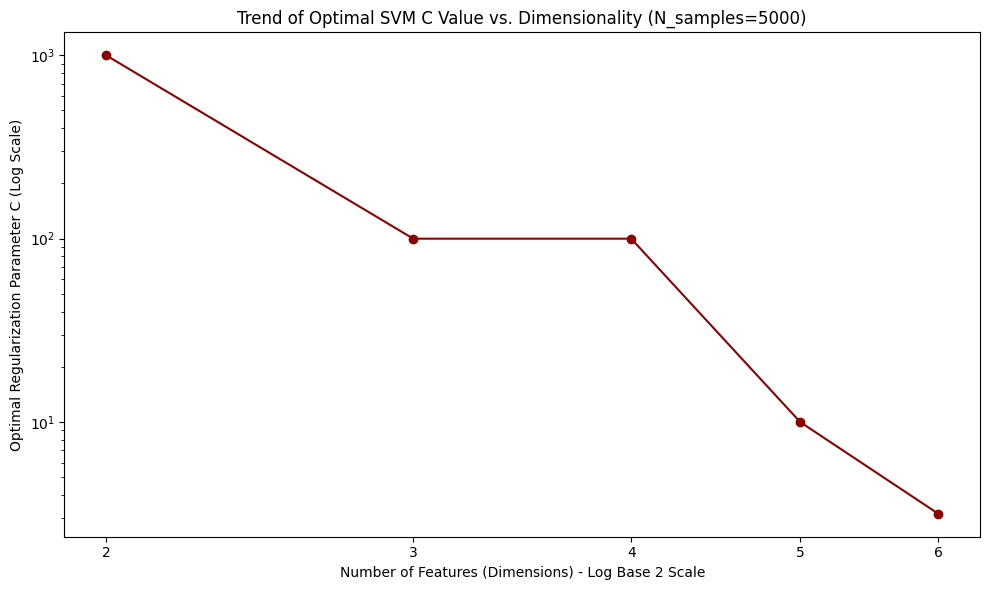

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

n = 5000
randomseed = 42
dimensions_to_test = list(range(2, 7))
C_range = np.logspace(-3, 3, 13)


optimal_c_results = {}


for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")


    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    #use a pipeline to prevent data leakage and to scale the data cuz svm is not scale invariant
    pipeline = make_pipeline(StandardScaler(), SVC(random_state=randomseed))

    param_grid = {'svc__C': C_range}
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    grid_search.fit(X, y)


    optimal_c = grid_search.best_params_['svc__C']
    optimal_c_results[D] = optimal_c

    print(f"Optimal C found: {optimal_c}. (Best CV Score: {grid_search.best_score_:.4f})")



dimensions = list(optimal_c_results.keys())
optimal_Cs = list(optimal_c_results.values())

plt.figure(figsize=(10, 6))

#plotting

plt.plot(dimensions, optimal_Cs, marker='o', linestyle='-', color='darkred')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of Features (Dimensions) - Log Base 2 Scale')
plt.ylabel('Optimal Regularization Parameter C (Log Scale)')
plt.title(f'Trend of Optimal SVM C Value vs. Dimensionality (N_samples={n})')
plt.xticks(dimensions, labels=dimensions)
plt.tight_layout()
plt.show()
